# 1 EDA - Survey Data

Objective: To explore what is included in the survey data.

Jimuel Celeste (jimueljr@ualberta.ca)

September 3, 2026

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data

In [2]:
data = "/Users/jimuelcelestejr/Documents/codebook/transparency_simulations/data/1_williams/coraliewilliams/coraliewilliams-simsurvey-ff13508/data/survey/simulationSurvey_extraction_100papers.xlsx"
df = pd.read_excel(data)
df.shape

(100, 83)

In [3]:
df.columns

Index(['YY_cross_check', 'Timestamp', 'initials_extractor', 'paper_title',
       'first_author', 'paper_year', 'journal', 'DOI_correction', 'DOI',
       '1.1.aims_reporting', '1.1.aims_reporting_comment',
       '1.2.aims_reportingsection', '1.2.aims_reportingsection_comment',
       '1.3.aims_purpose', '1.3.aims_purpose_comment', '2.1.datagen_reporting',
       '2.1.datagen_reporting_comment', '2.2.datagen_reportingsection',
       '2.2.datagen_reportingsection_comment', '2.3.datagen_type',
       '2.3.datagen_type_comment', '2.4.datagen_informed',
       '2.4.datagen_informed_comment', '2.5.1.datagen_parameters',
       '2.5.2.datagen_parameters_section', '2.6.1.datagen_conditions',
       '2.6.2.datagen_conditions_section', '2.6.datagen_conditions_comment',
       '2.7.1.datagen_simulationruns', '2.7.2.datagen_simulationruns_section',
       '2.7.datagen_simulationruns_comment', '2.8.datagen_distribution',
       '3.1.estimandtarget_reporting', '3.1.estimandtarget_reporting_commen

Is there a mapping to the checklist?

In [4]:
checklist = [
    "1.1.aims_reporting", 
    "2.1.datagen_reporting", 
    "3.1.estimandtarget_reporting", 
    "4.1.method_reporting", 
    "5.1.perfmeasures_reporting",
    "6.1.software_reporting",
    "7.1.code_datagen",
    "8.1.code_perfmeasures",
    "9.1.analysis_exploratory",
    "10.1.analysis_perfmeasures_reporting",
    "11.1.analysis_montecarlo_uncertainty",
]

In [5]:
df[checklist]

,1.1.aims_reporting,2.1.datagen_reporting,3.1.estimandtarget_reporting,4.1.method_reporting,5.1.perfmeasures_reporting,6.1.software_reporting,7.1.code_datagen,8.1.code_perfmeasures,9.1.analysis_exploratory,10.1.analysis_perfmeasures_reporting,11.1.analysis_montecarlo_uncertainty
0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
1,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,Yes,Yes
2,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,Yes,Yes
3,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes
4,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...
95,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No
96,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No
97,Yes,Yes,Yes,NaN,Yes,Yes,Yes,Yes,Yes,Yes,No
98,Yes,Yes,Yes,Yes,Yes,No,No,No,No,Yes,NaN


In [6]:
df[checklist].describe()

,1.1.aims_reporting,2.1.datagen_reporting,3.1.estimandtarget_reporting,4.1.method_reporting,5.1.perfmeasures_reporting,6.1.software_reporting,7.1.code_datagen,8.1.code_perfmeasures,9.1.analysis_exploratory,10.1.analysis_perfmeasures_reporting,11.1.analysis_montecarlo_uncertainty
count,100,100,100,97,100,100,100,99,100,100,98
unique,2,1,1,2,2,2,2,2,2,2,2
top,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No
freq,91,100,100,96,91,91,75,65,72,96,81


In [7]:
df[checklist].isna().sum()

1.1.aims_reporting                      0
2.1.datagen_reporting                   0
3.1.estimandtarget_reporting            0
4.1.method_reporting                    3
5.1.perfmeasures_reporting              0
6.1.software_reporting                  0
7.1.code_datagen                        0
8.1.code_perfmeasures                   1
9.1.analysis_exploratory                0
10.1.analysis_perfmeasures_reporting    0
11.1.analysis_montecarlo_uncertainty    2
dtype: int64

Missing values need to be resolved.

## Data Preparation

Label for machine learning: sum of the 11 items. 

Annotation rule: 
* Yes = 1 
* No = 0 
* NA = 0 (missing value)

In [8]:
for item in checklist:
    df[item] = df[item].map({"Yes": 1, "No": 0}).fillna(0)

Checkpoint: Are missing values resolved?

In [9]:
df[checklist].isna().sum()

1.1.aims_reporting                      0
2.1.datagen_reporting                   0
3.1.estimandtarget_reporting            0
4.1.method_reporting                    0
5.1.perfmeasures_reporting              0
6.1.software_reporting                  0
7.1.code_datagen                        0
8.1.code_perfmeasures                   0
9.1.analysis_exploratory                0
10.1.analysis_perfmeasures_reporting    0
11.1.analysis_montecarlo_uncertainty    0
dtype: int64

In [10]:
df["checklist_sum"] = df[checklist].sum(axis=1)

## Distribution

In [11]:
df["checklist_sum"].value_counts().sort_index()

checklist_sum
5.0      1
6.0      4
7.0      7
8.0     22
9.0     28
10.0    30
11.0     8
Name: count, dtype: int64

Skewed distribution; underrepresented lower numbers, unrepresented lower numbers; underrepresented highest number. Potential solution: https://imbalancedlearningregression.readthedocs.io/en/latest/smote.html 

Text(0, 0.5, 'Articles')

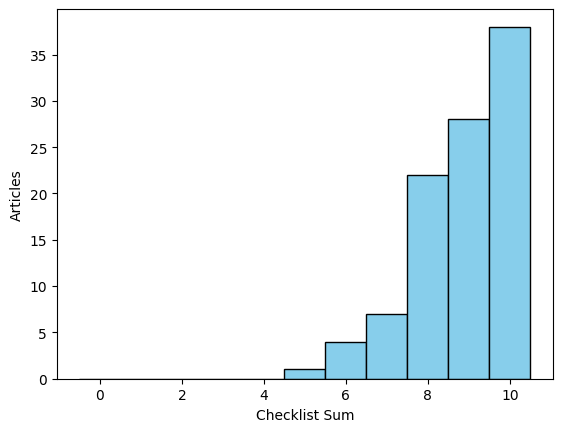

In [12]:
bin_edges = list(range(0, 12))
plt.hist(df['checklist_sum'], bins=bin_edges, color='skyblue', edgecolor='black', align='left')
plt.xlabel("Checklist Sum")
plt.ylabel("Articles")

## Metadata

In [13]:
metadata = [
    "paper_title", 
    "first_author", 
    "paper_year", 
    "journal", 
    "DOI"
]

In [14]:
df[metadata].isna().sum()

paper_title     0
first_author    0
paper_year      0
journal         0
DOI             0
dtype: int64

In [15]:
df['DOI'] = df['DOI'].apply(lambda doi: doi.strip())

In [16]:
df["paper_year"].value_counts().sort_index()

paper_year
2017     5
2018    26
2019    17
2020    26
2021    14
2022    12
Name: count, dtype: int64

In [17]:
df["journal"].value_counts()

journal
Methods in Ecology and Evolution              28
Ecological Applications                        9
Ecology and Evolution                          8
Ecology                                        5
Ecosphere                                      5
OIKOS                                          2
Evolution                                      2
Behavioral Ecology and Sociobiology            2
Ecography                                      2
Heredity                                       2
Movement Ecology                               2
Global Ecology and Biogeography                2
Journal of Animal Ecology                      2
Systematic Biology                             2
Ecological Informatics                         2
Molecular Ecology                              1
Oryx                                           1
The Journal of Wildlife Management             1
Diversity and Distributions                    1
Diversity and Distributions                    1
Molecular Ec

## Output

In [18]:
output_file = "../output/metadata.csv"
df[metadata + checklist + ["checklist_sum"]].to_csv(output_file, index=False)